In [2]:
import pandas as pd
from config import DATA_DIR, CHARTS_DIR
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy

## Data loading

In [3]:
print("Loading data to RAM...")
csv_file_path = DATA_DIR / 'processed_data.csv'

df = pd.read_csv(csv_file_path)
print("Data loaded successfully!")

Loading data to RAM...
Data loaded successfully!


## Wykres entropii dla każdego ECU

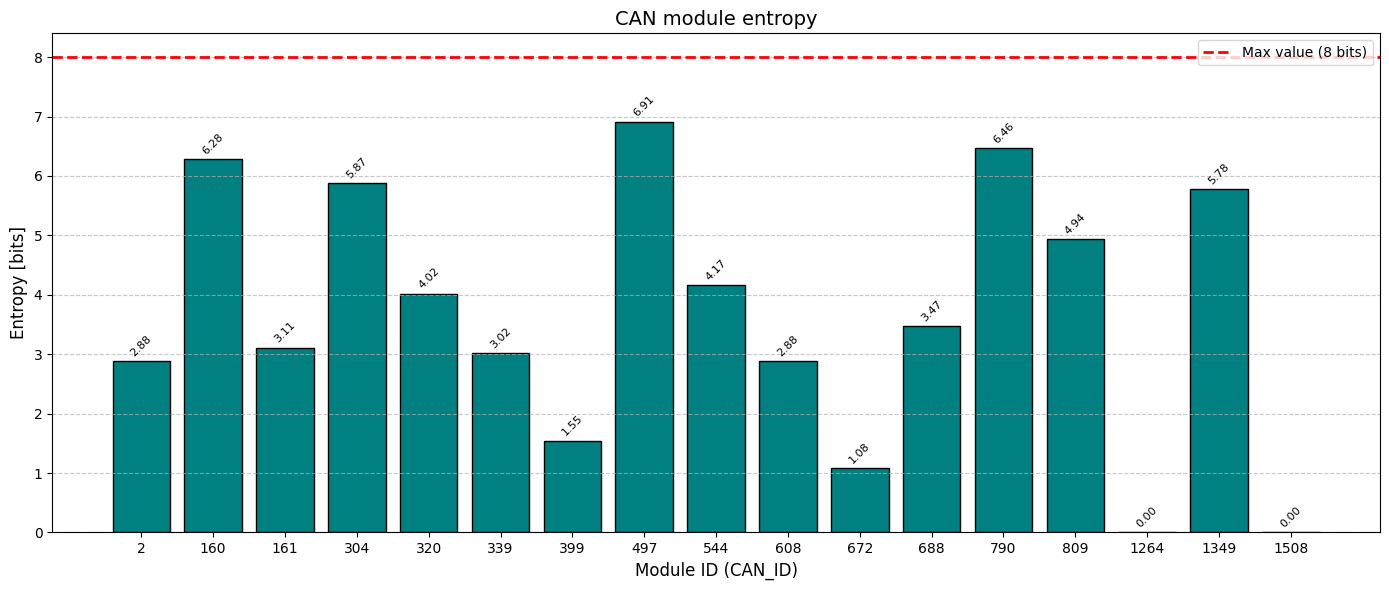

In [4]:
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

unique_ids = sorted(df['CAN_ID'].unique())
byte_cols = [col for col in df.columns if 'Byte' in col]
entropy_results = []

for i, can_id in enumerate(unique_ids):
    df_module = df[df['CAN_ID'] == can_id].copy()

    if len(df_module) < 100:
        continue

    flat_bytes = df_module[byte_cols].values.flatten()
    flat_bytes = flat_bytes[~np.isnan(flat_bytes)]
    flat_bytes = flat_bytes[flat_bytes >= 0]

    if len(flat_bytes) == 0:
        continue

    counts = np.bincount(flat_bytes.astype(int), minlength=256)
    ent = entropy(counts, base=2)

    entropy_results.append({
        'CAN_ID': str(can_id),
        'Global_Entropy': ent
    })

df_ent = pd.DataFrame(entropy_results)

plt.figure(figsize=(14, 6))
bars = plt.bar(df_ent['CAN_ID'], df_ent['Global_Entropy'], color='teal', edgecolor='black')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.05, f'{yval:.2f}', ha='center', va='bottom', fontsize=8, rotation=45)

plt.title('CAN module entropy', fontsize=14)
plt.xlabel('Module ID (CAN_ID)', fontsize=12)
plt.ylabel('Entropy [bits]', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.axhline(8.0, color='red', linestyle='dashed', linewidth=2, label='Max value (8 bits)')
plt.legend()

plt.tight_layout()
plt.savefig(CHARTS_DIR / 'CAN ECU Entropy')
plt.show()